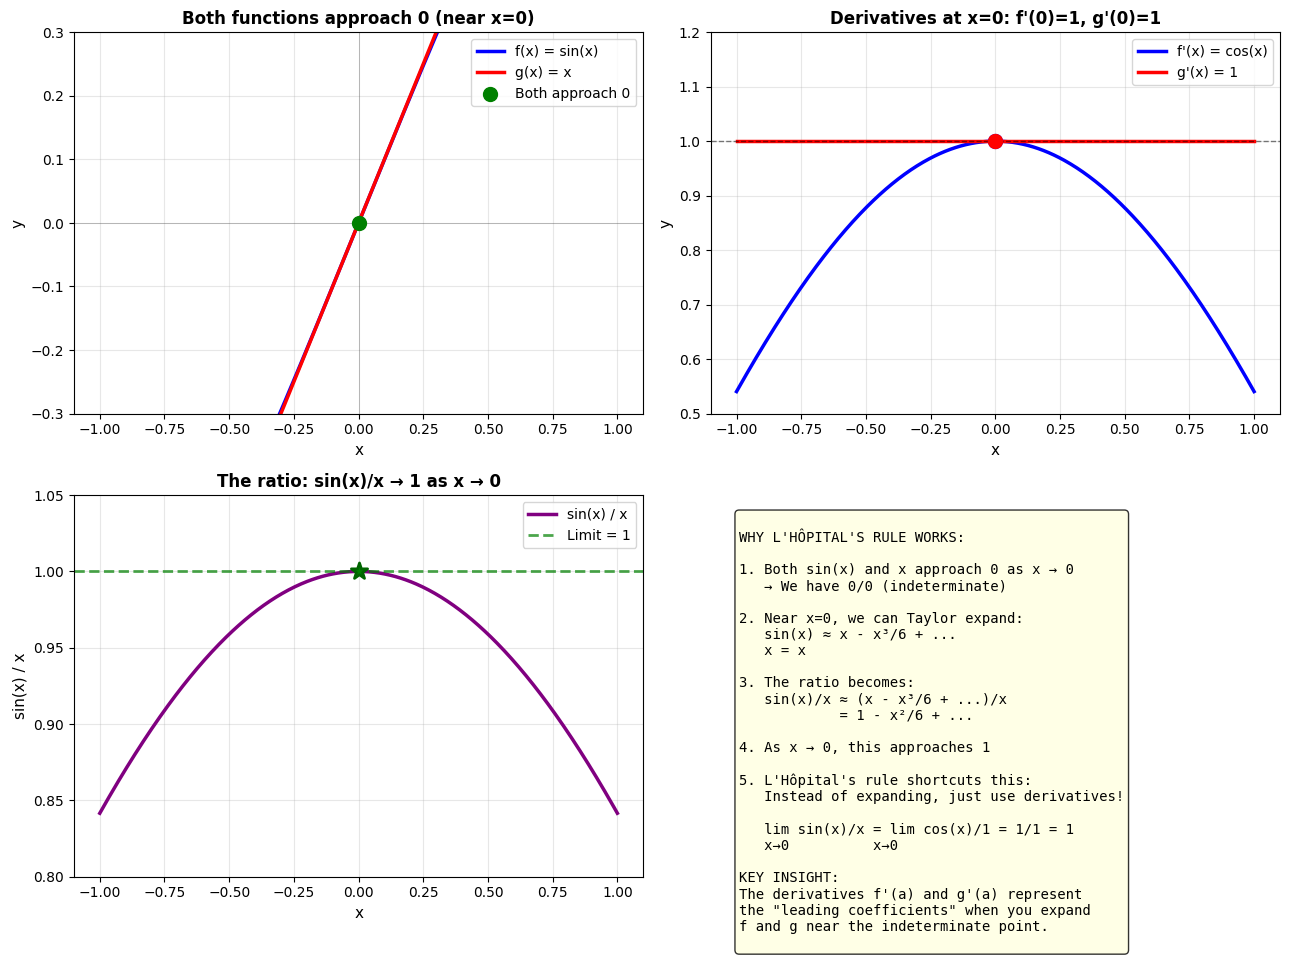

NUMERICAL VERIFICATION: sin(x)/x as x → 0
x =      0.1 : sin(x)/x = 0.9983341665
x =     0.01 : sin(x)/x = 0.9999833334
x =    0.001 : sin(x)/x = 0.9999998333
x =   0.0001 : sin(x)/x = 0.9999999983
x =    1e-05 : sin(x)/x = 1.0000000000

L'Hôpital result: cos(0)/1 = 1.0000000000


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Define functions
def f(x):
    return np.sin(x)

def g(x):
    return x

def ratio(x):
    # Avoid division by zero
    return np.sin(x) / x

# Derivatives
def f_prime(x):
    return np.cos(x)

def g_prime(x):
    return np.ones_like(x)

# Create x values, avoiding x=0
x = np.linspace(-1, 1, 500)
x = x[x != 0]  # Remove x=0

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Plot 1: sin(x) and x together
ax = axes[0, 0]
ax.plot(x, f(x), 'b-', linewidth=2.5, label='f(x) = sin(x)')
ax.plot(x, g(x), 'r-', linewidth=2.5, label='g(x) = x')
ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax.scatter([0], [0], s=100, c='green', marker='o', zorder=5, label='Both approach 0')
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.set_title('Both functions approach 0 (near x=0)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([-0.3, 0.3])

# Plot 2: Derivatives
ax = axes[0, 1]
ax.plot(x, f_prime(x), 'b-', linewidth=2.5, label="f'(x) = cos(x)")
ax.plot(x, g_prime(x), 'r-', linewidth=2.5, label="g'(x) = 1")
ax.axhline(1, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax.scatter([0], [1], s=100, c='blue', marker='o', zorder=5)
ax.scatter([0], [1], s=100, c='red', marker='o', zorder=5)
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.set_title("Derivatives at x=0: f'(0)=1, g'(0)=1", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([0.5, 1.2])

# Plot 3: The ratio
ax = axes[1, 0]
ax.plot(x, ratio(x), 'purple', linewidth=2.5, label='sin(x) / x')
ax.axhline(1, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Limit = 1')
ax.scatter([0], [1], s=150, c='green', marker='*', zorder=5, edgecolors='darkgreen', linewidths=2)
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('sin(x) / x', fontsize=11)
ax.set_title('The ratio: sin(x)/x → 1 as x → 0', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_ylim([0.8, 1.05])

# Plot 4: Annotated explanation
ax = axes[1, 1]
ax.axis('off')

explanation = """
WHY L'HÔPITAL'S RULE WORKS:

1. Both sin(x) and x approach 0 as x → 0
   → We have 0/0 (indeterminate)

2. Near x=0, we can Taylor expand:
   sin(x) ≈ x - x³/6 + ...
   x = x
   
3. The ratio becomes:
   sin(x)/x ≈ (x - x³/6 + ...)/x
            = 1 - x²/6 + ...
   
4. As x → 0, this approaches 1

5. L'Hôpital's rule shortcuts this:
   Instead of expanding, just use derivatives!
   
   lim sin(x)/x = lim cos(x)/1 = 1/1 = 1
   x→0          x→0

KEY INSIGHT:
The derivatives f'(a) and g'(a) represent
the "leading coefficients" when you expand
f and g near the indeterminate point.
"""

ax.text(0.05, 0.95, explanation, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('/tmp/lhopital.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("NUMERICAL VERIFICATION: sin(x)/x as x → 0")
print("=" * 60)
x_vals = [0.1, 0.01, 0.001, 0.0001, 0.00001]
for x_val in x_vals:
    ratio_val = np.sin(x_val) / x_val
    print(f"x = {x_val:>8} : sin(x)/x = {ratio_val:.10f}")
print(f"\nL'Hôpital result: cos(0)/1 = {np.cos(0):.10f}")